# IMKA evaluation summary — `imka` run

Plots a summary of one evaluation run from three files in the same folder as this notebook (`test/output/`):

| File | Produced by | What it holds |
|---|---|---|
| `answers-<run>.json` | `run-questions-imka.py` | question, rewritten query, answer, citations, context, latency |
| `ragas-<run>.json` | `evaluate-ragas.py` | RAGAS scores per question, per judge (`luna` primary, `qwen` secondary) |
| `retrieval-<run>.json` | `evaluate-retrieval.py` | page-level hit@k / MRR of the reranked context |

Change `RUN` below to summarize a different run with the same file layout.
RAGAS charts are drawn for every judge that has scored all scoreable questions; a judge that is still
part-way through is listed in the coverage table but not charted.
Needs `pandas` and `matplotlib` (`pip install pandas matplotlib`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

RUN = "imka"
ACCURACY_PASS = 1.0   # answer_accuracy at or above this counts as a correct answer
SAVE_FIGS = False     # True writes each figure to figures-<RUN>/ next to the data

# The notebook lives in test/output/; also works if the kernel starts in test/ or the repo root.
OUTPUT_DIR = next(p for p in (Path("."), Path("output"), Path("test/output"))
                  if (p / f"answers-{RUN}.json").is_file())
FIG_DIR = OUTPUT_DIR / f"figures-{RUN}"


def load(kind):
    with open(OUTPUT_DIR / f"{kind}-{RUN}.json", encoding="utf-8") as f:
        return json.load(f)


answers = load("answers")
ragas = load("ragas")
retrieval = load("retrieval")
print(f"Loaded from {OUTPUT_DIR.resolve()}")

Loaded from D:\git\fumeng1994\IMKA_Knowledge_Assistant_ChatBot\test\output


In [2]:
# Chart style: light surface, recessive grid/axes, fixed categorical order.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# Score scale for RAGAS: red = bad (0), neutral gray = middling (0.5), green = good (1).
RED_GREEN = LinearSegmentedColormap.from_list(
    "red_green", ["#a82b2b", "#d03b3b", "#ec9a8f", "#f0efec", "#8fcf8f", "#2e9e2e", "#0a6e0a"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.labelcolor": INK_2,
    "lines.linewidth": 2, "patch.linewidth": 0,
})


def finish(fig, name):
    fig.tight_layout()
    if SAVE_FIGS:
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def heatmap(ax, table, vmin=0.0, vmax=1.0, fmt="{:.2f}", cmap=BLUES):
    # Heatmap with value labels; NaN cells stay blank.
    data = table.to_numpy(dtype=float)
    ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(table.shape[0]), table.index)
    ax.grid(False)
    for side in ax.spines.values():
        side.set_visible(False)
    # 2px surface gap between cells
    ax.set_xticks(np.arange(-0.5, table.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, table.shape[0]), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="minor", length=0)
    for (i, j), v in np.ndenumerate(data):
        if not np.isnan(v):
            t = (v - vmin) / (vmax - vmin)
            # BLUES darkens toward 1; RED_GREEN darkens toward both ends.
            dark_cell = abs(t - 0.5) > 0.3 if cmap is RED_GREEN else t > 0.55
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=9,
                    color="#ffffff" if dark_cell else INK)

## Run overview

In [3]:
ans = pd.DataFrame(answers["results"])
ans["answer_chars"] = ans["answer"].str.len()
ans["n_citations"] = ans["citations"].apply(len)
ans["cited_pages"] = ans["citations"].apply(lambda cs: sorted({c.get("page") for c in cs if c.get("page") is not None}))

overview = pd.Series({
    "answers generated": answers["generated_at"],
    "questions answered": f'{answers["count"]} / {answers["total"]}',
    "generation errors": answers["errors"],
    "latency median (s)": round(ans["elapsed_s"].median(), 1),
    "latency p90 (s)": round(ans["elapsed_s"].quantile(0.9), 1),
    "latency max (s)": round(ans["elapsed_s"].max(), 1),
    "total generation time (min)": round(ans["elapsed_s"].sum() / 60, 1),
    "RAGAS scored": ragas["generated_at"],
    "retrieval scored": f'{retrieval["count"]} / {retrieval["questions_total"]} questions',
    "retrieval skipped": ", ".join(f'Q{s["id"]}' for s in retrieval["skipped"]) or "none",
}, name="value")
overview.to_frame()

,value
answers generated,2026-09-17T17:45:43
questions answered,70 / 70
generation errors,0
latency median (s),3.2
latency p90 (s),3.7
latency max (s),9.1
total generation time (min),3.8
RAGAS scored,2026-09-18T00:36:48
retrieval scored,67 / 70 questions
retrieval skipped,"Q68, Q69, Q70"


In [4]:
# Judge coverage. Only judges that scored every scoreable question are charted below.
JUDGE_ORDER = ["luna", "qwen"]  # primary first
SCOREABLE = ragas["questions_total"] - len(ragas["skipped"])
JUDGES = [k for k in JUDGE_ORDER + sorted(set(ragas["judges"]) - set(JUDGE_ORDER))
          if k in ragas["judges"] and ragas["judges"][k]["count"] >= SCOREABLE]
PRIMARY = JUDGES[0] if JUDGES else None  # judge behind "correct" in section 4


def judge_label(judge):
    return f"{judge} ({ragas['judges'][judge]['model']})"


print(f"Charted judges: {', '.join(map(judge_label, JUDGES)) or 'none'}")
pd.DataFrame({
    name: {"judge model": j["model"], "provider": j["provider"], "metric API": j["metric_api"],
           "questions scored": f'{j["count"]} / {SCOREABLE}', "errors": j["errors"], "charted": name in JUDGES}
    for name, j in ragas["judges"].items()
}).T

Charted judges: luna (gpt-5.6-luna), qwen (qwen3.8-27b-q4)


,judge model,provider,metric API,questions scored,errors,charted
luna,gpt-5.6-luna,openai,collections,70 / 70,0,True
qwen,qwen3.8-27b-q4,runpod,legacy,70 / 70,0,True


## 1. Answers (`answers-*.json`)

Latency per question and how the question set is spread across the RAG component each question targets.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


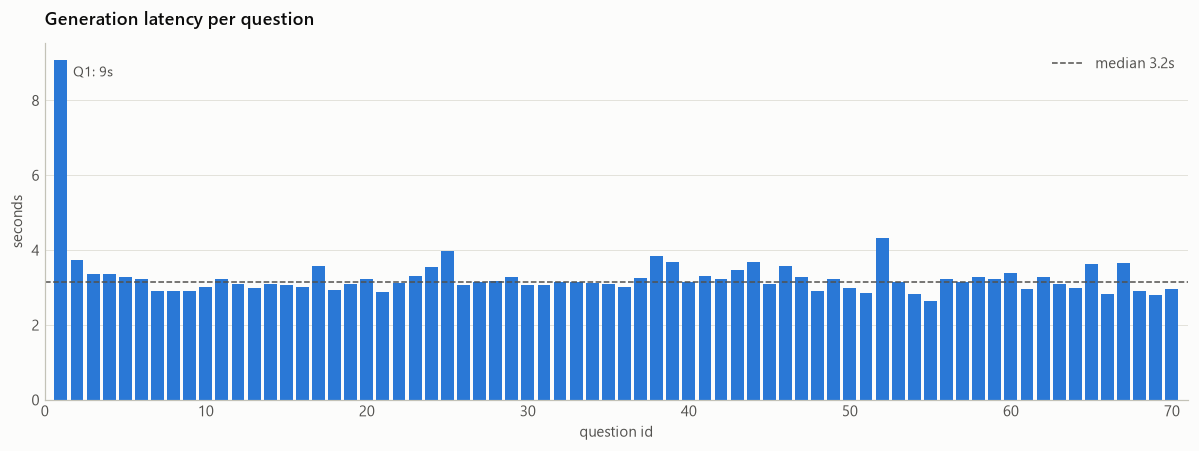

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(ans["id"], ans["elapsed_s"], width=0.8, color=SERIES[0])
med = ans["elapsed_s"].median()
ax.axhline(med, color=INK_2, linewidth=1, linestyle="--", label=f"median {med:.1f}s")
ax.legend(loc="upper right")
slowest = ans.loc[ans["elapsed_s"].idxmax()]
ax.annotate(f'Q{slowest["id"]}: {slowest["elapsed_s"]:.0f}s', (slowest["id"], slowest["elapsed_s"]),
            xytext=(8, -4), textcoords="offset points", va="top", color=INK_2, fontsize=9)
ax.set(title="Generation latency per question", xlabel="question id", ylabel="seconds", xlim=(0, ans["id"].max() + 1))
ax.grid(axis="x", visible=False)
finish(fig, "answers-latency")

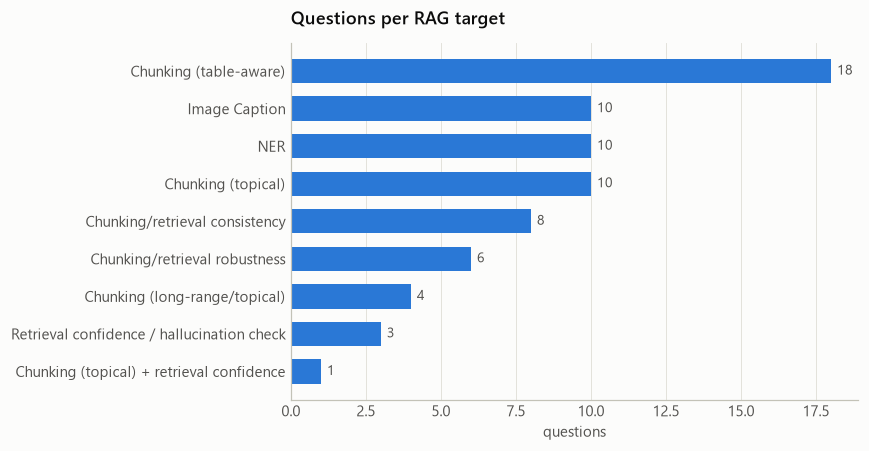

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
counts = ans["rag_target"].value_counts().sort_values()
ax.barh(counts.index, counts.values, height=0.65, color=SERIES[0])
for y, v in enumerate(counts.values):
    ax.text(v + 0.2, y, str(v), va="center", color=INK_2, fontsize=9)
ax.set(title="Questions per RAG target", xlabel="questions")
ax.grid(axis="y", visible=False)
finish(fig, "answers-targets")

C:\Users\fumen\AppData\Local\Temp\ipykernel_38840\204139746.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(groups, vert=False, tick_labels=[f"{t}  (n={len(g)})" for t, g in zip(order, groups)], widths=0.5,


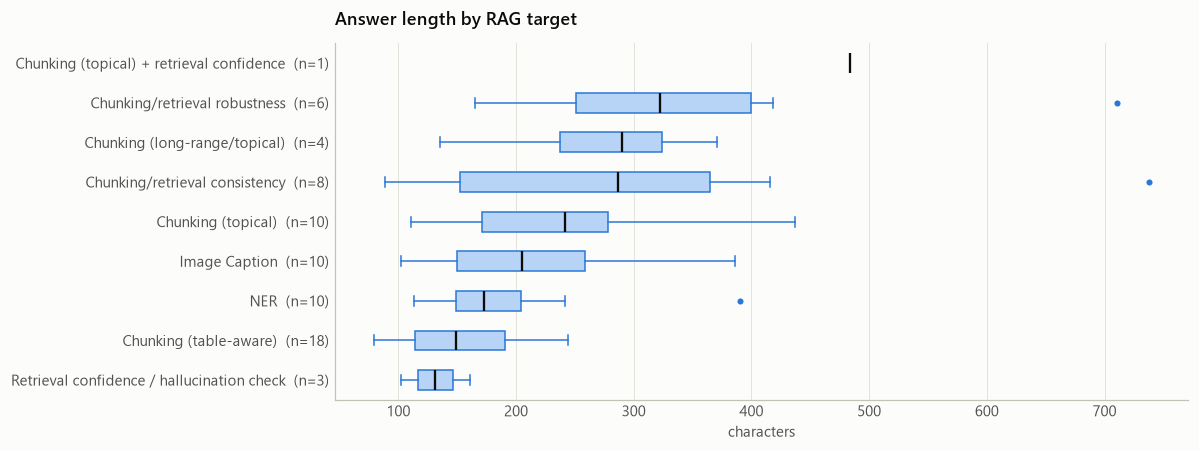

Citations per answer: {1: 70} (deduplicated by document_id)


In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))
order = ans.groupby("rag_target")["answer_chars"].median().sort_values().index
groups = [ans.loc[ans["rag_target"] == t, "answer_chars"] for t in order]
ax.boxplot(groups, vert=False, tick_labels=[f"{t}  (n={len(g)})" for t, g in zip(order, groups)], widths=0.5,
           patch_artist=True, medianprops={"color": INK, "linewidth": 1.5},
           boxprops={"facecolor": "#b7d3f6", "edgecolor": SERIES[0]},
           whiskerprops={"color": SERIES[0]}, capprops={"color": SERIES[0]},
           flierprops={"marker": "o", "markersize": 5, "markerfacecolor": SERIES[0], "markeredgecolor": SURFACE})
ax.set(title="Answer length by RAG target", xlabel="characters")
ax.grid(axis="y", visible=False)
finish(fig, "answers-length")
print("Citations per answer:", ans["n_citations"].value_counts().sort_index().to_dict(),
      "(deduplicated by document_id)")

## 2. RAGAS scores (`ragas-*.json`)

All metrics are 0–1, higher is better. *Absence probes* are fabricated questions whose correct answer is
"not in the manual", so they are shown separately — they inflate some metrics and deflate others.

Each chart is drawn once per complete judge. When both judges are complete, a judge-comparison chart follows.

In [8]:
METRICS = ragas["metrics"]
SLICES = {"all questions": "overall", "excluding absence probes": "excluding_absence_probes",
          "absence probes only": "absence_probes_only"}

scores_by_judge = {
    judge: pd.DataFrame([
        {"id": r["id"], "failure_type": r["failure_type"], "rag_target": r["rag_target"],
         "absence": r["reference_is_absence"], **r["scores"][judge]}
        for r in ragas["results"] if r["scores"].get(judge)
    ])
    for judge in JUDGES
}


def judge_summary(judge):
    agg = ragas["aggregate"][judge]
    t = pd.DataFrame({label: {m: agg[key][m]["mean"] for m in METRICS} for label, key in SLICES.items()})
    t.loc["questions"] = [agg[key]["questions"] for key in SLICES.values()]
    return t


summaries = {judge: judge_summary(judge) for judge in JUDGES}
if not JUDGES:
    print("No judge has scored every question yet — RAGAS charts are skipped. "
          "Run evaluate-ragas.py --luna and/or --qwen to completion.")
pd.concat(summaries, axis=1) if JUDGES else None

luna                           \
                    all questions excluding absence probes   
faithfulness               0.9107                   0.9102   
answer_relevancy           0.6472                   0.6809   
context_precision          0.6352                   0.6182   
context_recall             0.6893                   0.6680   
answer_accuracy            0.6643                   0.6562   
semantic_similarity        0.4096                   0.4088   
questions                 70.0000                  64.0000   

                                                 qwen  \
                    absence probes only all questions   
faithfulness                     0.9167        0.9179   
answer_relevancy                 0.2875        0.5802   
context_precision                0.8157        0.6669   
context_recall                   0.9167        0.7000   
answer_accuracy                  0.7500        0.6357   
semantic_similarity              0.4173        0.4096   
questions                        6.0000       70.0000   

                                                                  
                    excluding absence probes absence probes only  
faithfulness                          0.9102              1.0000  
answer_relevancy                      0.6202              0.1539  
context_precision                     0.6469              0.8805  
context_recall                        0.6719              1.0000  
answer_accuracy                       0.6367              0.6250  
semantic_similarity                   0.4088              0.4173  
questions                            64.0000              6.0000

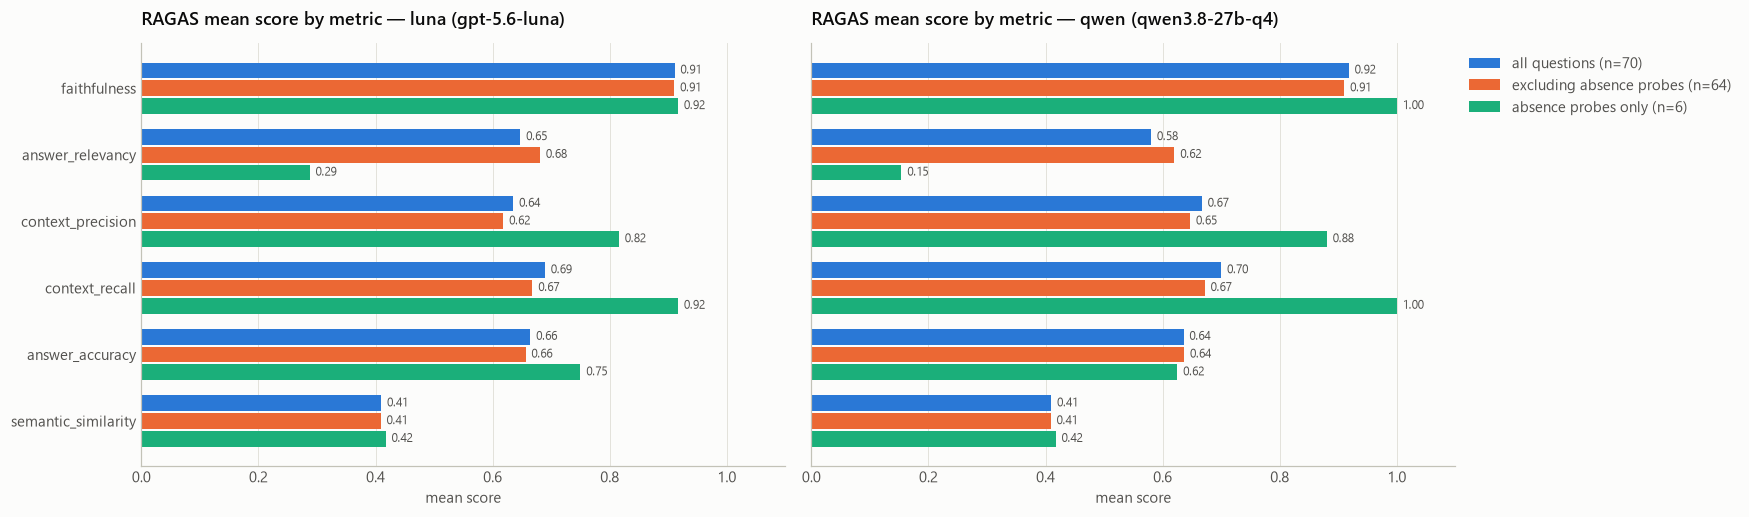

In [9]:
if JUDGES:
    fig, axes = plt.subplots(1, len(JUDGES), figsize=(6.5 * len(JUDGES) + 3, 4.8), sharey=True, squeeze=False)
    labels = list(SLICES)
    n = len(labels)
    h = 0.8 / n
    y = np.arange(len(METRICS))[::-1]
    for ax, judge in zip(axes[0], JUDGES):
        summary = summaries[judge]
        for i, label in enumerate(labels):
            vals = summary.loc[METRICS, label].astype(float).to_numpy()
            pos = y + (n - 1) / 2 * h - i * h
            ax.barh(pos, vals, height=h - 0.03, color=SERIES[i],
                    label=f"{label} (n={int(summary.loc['questions', label])})")
            for p, v in zip(pos, vals):
                if not np.isnan(v):
                    ax.text(v + 0.01, p, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
        ax.set_yticks(y, METRICS)
        ax.set(xlim=(0, 1.1), xlabel="mean score", title=f"RAGAS mean score by metric — {judge_label(judge)}")
        ax.grid(axis="y", visible=False)
    axes[0][-1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    finish(fig, "ragas-means")

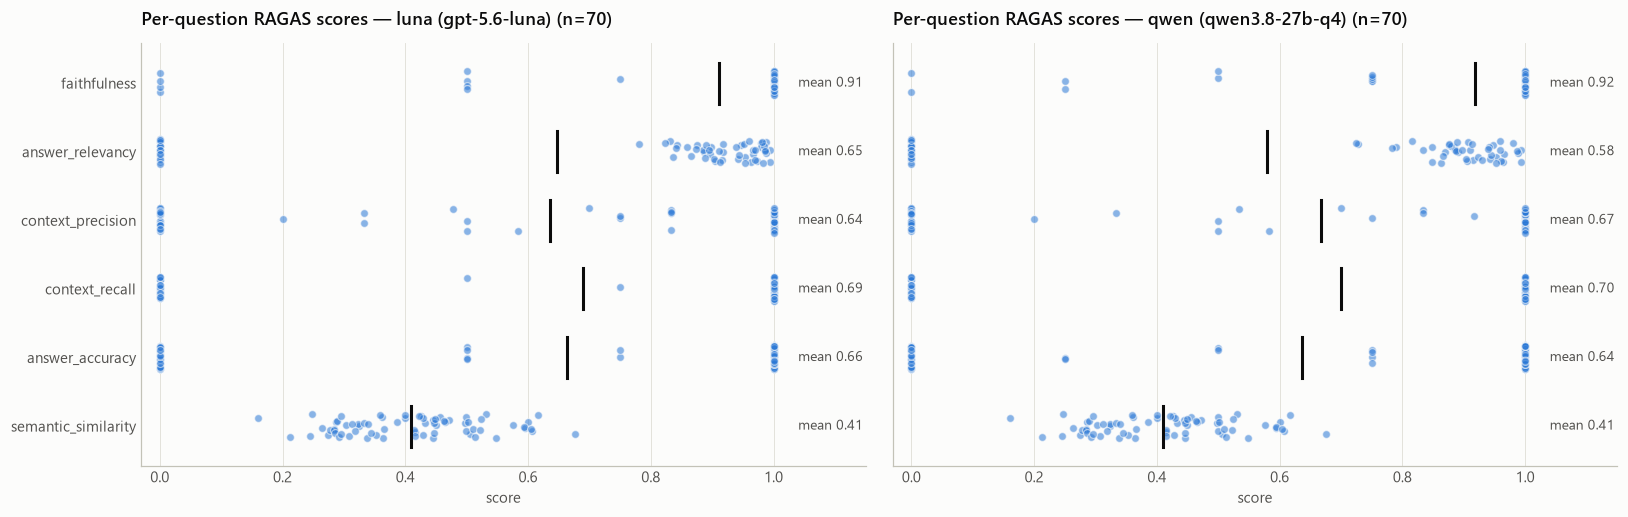

In [10]:
# Every question's score as a dot (jittered), with the mean as a dark bar.
if JUDGES:
    fig, axes = plt.subplots(1, len(JUDGES), figsize=(11 if len(JUDGES) == 1 else 7.5 * len(JUDGES), 4.8),
                             sharey=True, squeeze=False)
    for ax, judge in zip(axes[0], JUDGES):
        scores = scores_by_judge[judge]
        rng = np.random.default_rng(0)
        for i, m in enumerate(METRICS[::-1]):
            vals = scores[m].dropna()
            jitter = rng.uniform(-0.18, 0.18, len(vals))
            ax.scatter(vals, i + jitter, s=26, color=SERIES[0], alpha=0.55, edgecolor=SURFACE, linewidth=0.8)
            ax.plot([vals.mean()] * 2, [i - 0.3, i + 0.3], color=INK, linewidth=2)
            ax.text(1.04, i, f"mean {vals.mean():.2f}", va="center", fontsize=9, color=INK_2)
        ax.set_yticks(range(len(METRICS)), METRICS[::-1])
        ax.set(xlim=(-0.03, 1.15), xlabel="score",
               title=f"Per-question RAGAS scores — {judge_label(judge)} (n={len(scores)})")
        ax.grid(axis="y", visible=False)
    finish(fig, "ragas-distribution")

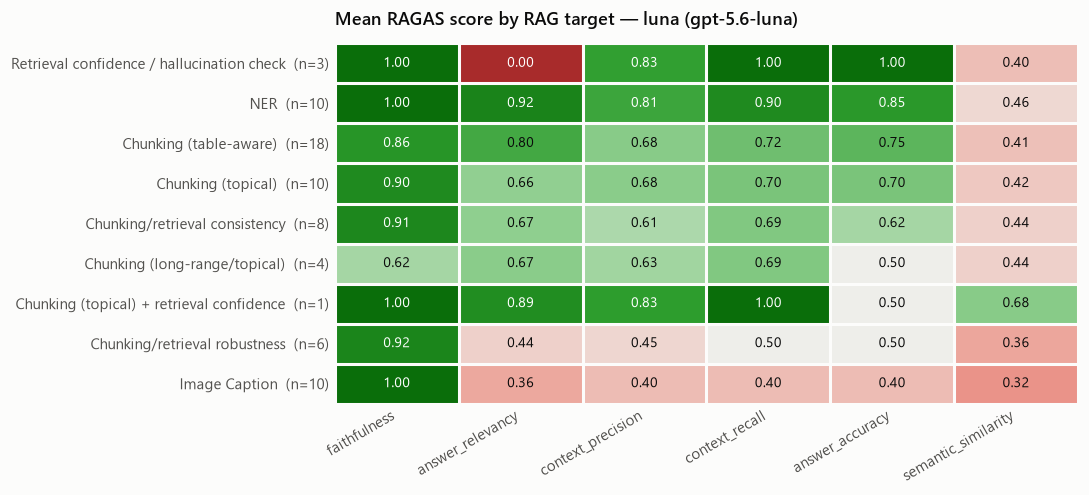

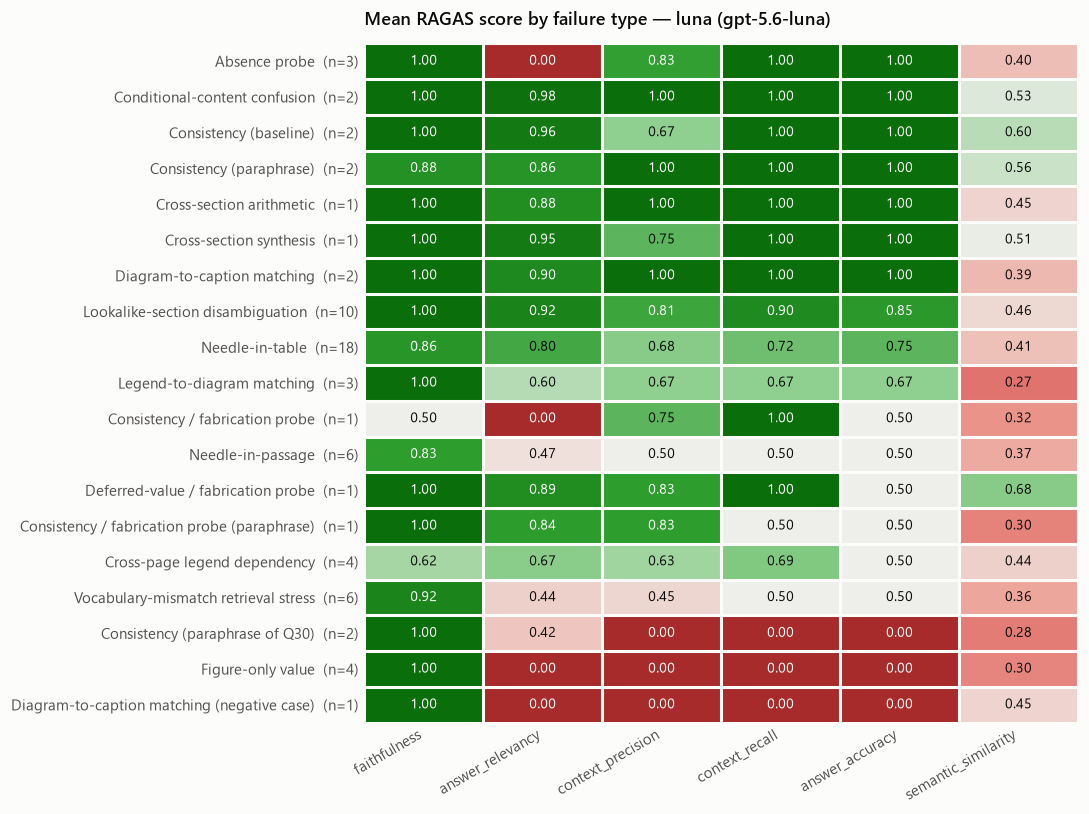

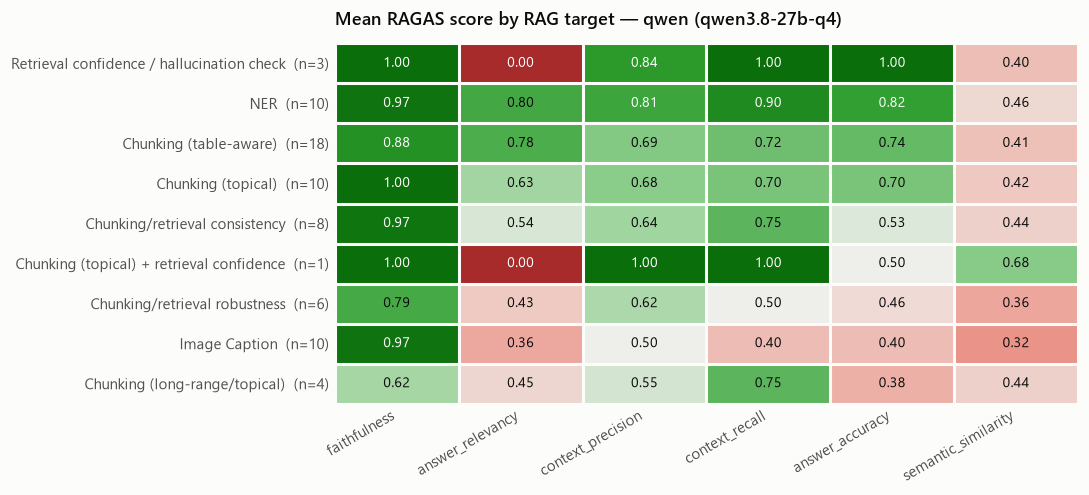

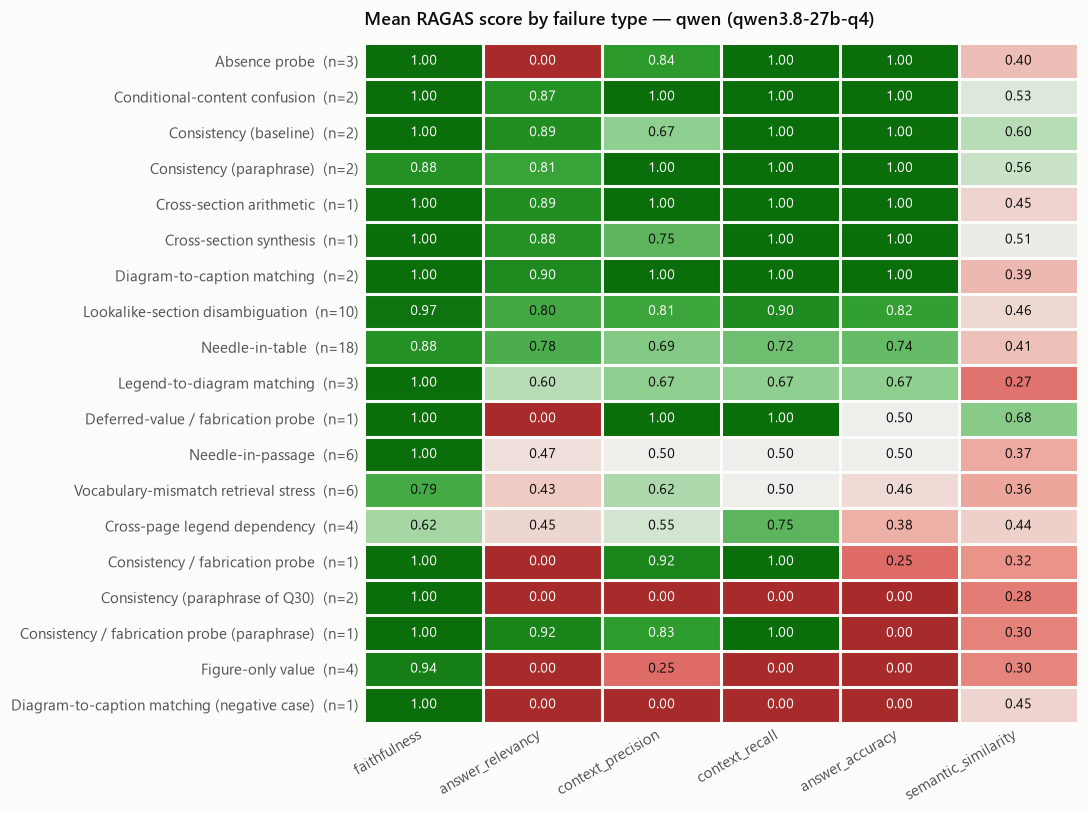

In [11]:
def by_group(df, col):
    t = df.groupby(col)[METRICS].mean()
    n = df[col].value_counts()
    t = t.sort_values("answer_accuracy", ascending=False)
    t.index = [f"{g}  (n={n[g]})" for g in t.index]
    return t


for judge in JUDGES:
    fig, ax = plt.subplots(figsize=(10, 4.6))
    heatmap(ax, by_group(scores_by_judge[judge], "rag_target"), cmap=RED_GREEN)
    ax.set_title(f"Mean RAGAS score by RAG target — {judge_label(judge)}")
    finish(fig, f"ragas-by-target-{judge}")

    fig, ax = plt.subplots(figsize=(10, 7.5))
    heatmap(ax, by_group(scores_by_judge[judge], "failure_type"), cmap=RED_GREEN)
    ax.set_title(f"Mean RAGAS score by failure type — {judge_label(judge)}")
    finish(fig, f"ragas-by-failure-type-{judge}")

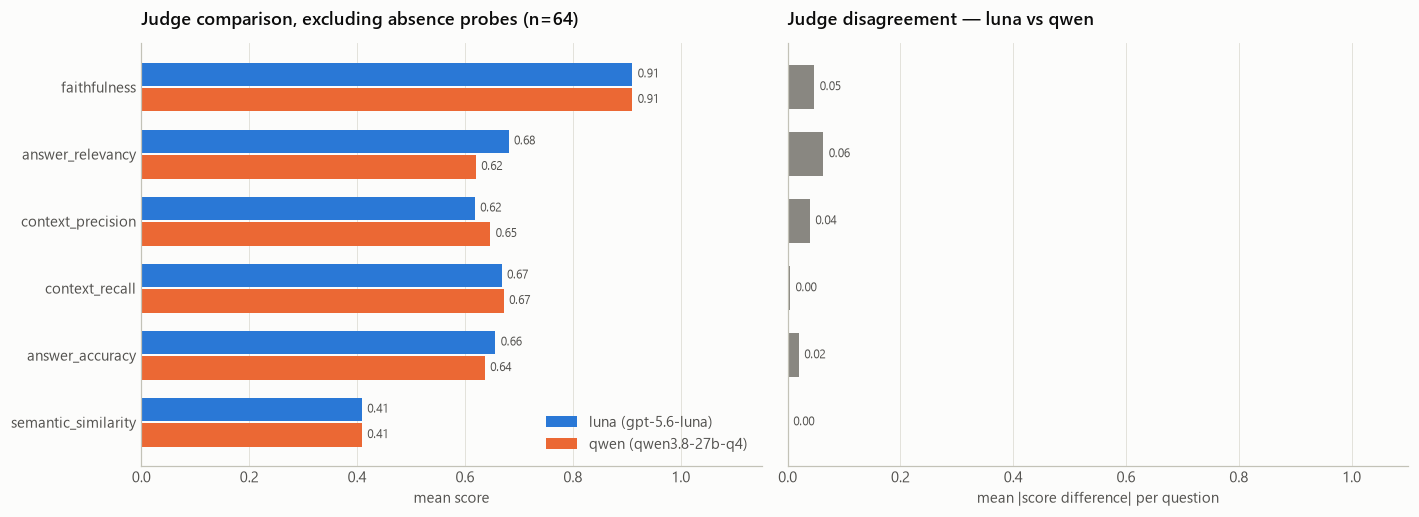

Correct/not-correct verdicts agree on 95% of 64 questions (answer_accuracy >= 1.0)


In [12]:
# Judge comparison — drawn only when both judges have scored every question.
if len(JUDGES) >= 2:
    a, b = JUDGES[:2]
    pair = scores_by_judge[a].merge(scores_by_judge[b][["id"] + METRICS], on="id", suffixes=(f"_{a}", f"_{b}"))
    graded = pair[~pair["absence"]]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
    y = np.arange(len(METRICS))[::-1]
    h = 0.38
    for i, judge in enumerate((a, b)):
        vals = graded[[f"{m}_{judge}" for m in METRICS]].mean().to_numpy()
        pos = y + (0.5 - i) * h
        ax1.barh(pos, vals, height=h - 0.03, color=SERIES[i], label=judge_label(judge))
        for p, v in zip(pos, vals):
            if not np.isnan(v):
                ax1.text(v + 0.01, p, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
    ax1.set_yticks(y, METRICS)
    ax1.set(xlim=(0, 1.15), xlabel="mean score", title=f"Judge comparison, excluding absence probes (n={len(graded)})")
    ax1.grid(axis="y", visible=False)
    ax1.legend(loc="lower right")

    diffs = [(graded[f"{m}_{a}"] - graded[f"{m}_{b}"]).abs().mean() for m in METRICS]
    ax2.barh(y, diffs, height=0.65, color=MUTED)
    for yy, v in zip(y, diffs):
        if not np.isnan(v):
            ax2.text(v + 0.01, yy, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
    ax2.set(xlim=(0, 1.1), xlabel="mean |score difference| per question", title=f"Judge disagreement — {a} vs {b}")
    ax2.grid(axis="y", visible=False)
    finish(fig, "ragas-judge-comparison")

    verdicts = graded[[f"answer_accuracy_{a}", f"answer_accuracy_{b}"]].dropna() >= ACCURACY_PASS
    agree = (verdicts.iloc[:, 0] == verdicts.iloc[:, 1]).mean()
    print(f"Correct/not-correct verdicts agree on {agree:.0%} of {len(verdicts)} questions "
          f"(answer_accuracy >= {ACCURACY_PASS})")
else:
    print("Judge comparison needs both judges to have scored every question — skipped.")

## 3. Retrieval (`retrieval-*.json`)

A retrieved chunk counts as relevant when its page matches a page named in the question's `source`.
`exact` requires the same page; `within_1_page` tolerates an off-by-one page (chunks that straddle a page break).
Ranked list = the final reranked context (top 5) the answer was generated from.

In [13]:
TOLS = ["exact", "within_1_page"]
KS = retrieval["method"]["k"]
ret = pd.DataFrame([
    {"id": r["id"], "failure_type": r["failure_type"], "rag_target": r["rag_target"],
     **{f"{tol}:{k}": v for tol in TOLS for k, v in r["metrics"][tol].items()}}
    for r in retrieval["results"]
])
overall = retrieval["aggregate"]["overall"]
pd.DataFrame({tol: overall[tol] for tol in TOLS})

,exact,within_1_page
hit_rate@1,0.6269,0.7612
hit_rate@3,0.6418,0.9104
hit_rate@5,0.6418,0.9254
mrr,0.6343,0.8271


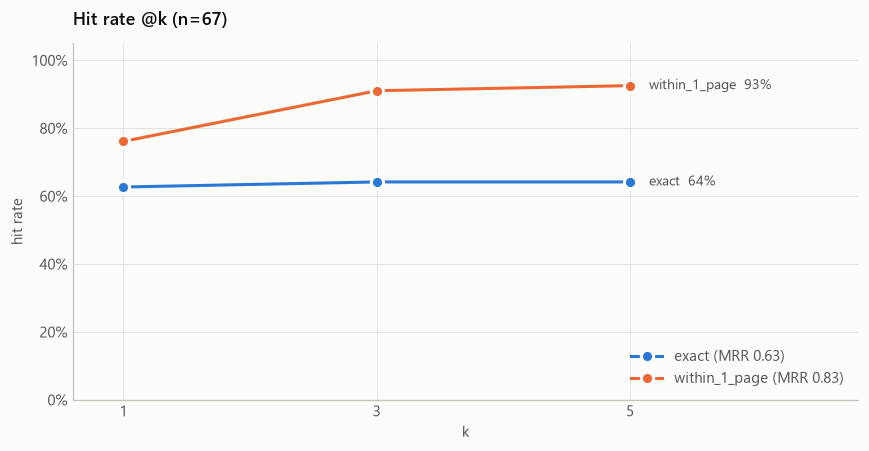

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, tol in enumerate(TOLS):
    vals = [overall[tol][f"hit_rate@{k}"] for k in KS]
    ax.plot(KS, vals, color=SERIES[i], marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2,
            label=f"{tol} (MRR {overall[tol]['mrr']:.2f})")
    ax.text(KS[-1] + 0.15, vals[-1], f"{tol}  {vals[-1]:.0%}", va="center", color=INK_2, fontsize=9)
ax.set(xticks=KS, xlim=(0.6, KS[-1] + 1.8), ylim=(0, 1.05), xlabel="k", ylabel="hit rate",
       title=f"Hit rate @k (n={overall['questions']})")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower right")
finish(fig, "retrieval-hit-rate")

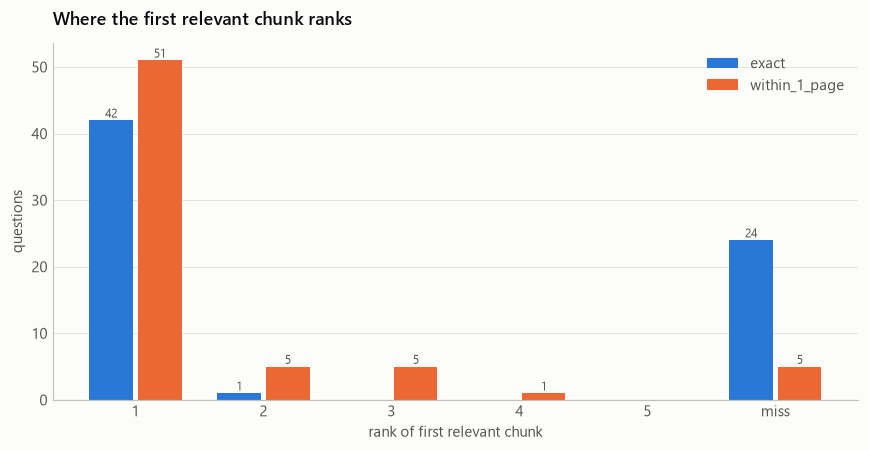

In [15]:
# Rank at which the first relevant chunk appeared; "miss" = not in the top 5.
fig, ax = plt.subplots(figsize=(8, 4.2))
max_k = retrieval["method"]["max_retrieved"]
ranks = [str(k) for k in range(1, max_k + 1)] + ["miss"]
x = np.arange(len(ranks))
w = 0.38
for i, tol in enumerate(TOLS):
    first = ret[f"{tol}:first_relevant_rank"].apply(lambda r: "miss" if pd.isna(r) else str(int(r)))
    cnt = first.value_counts().reindex(ranks, fill_value=0)
    pos = x + (i - 0.5) * w
    ax.bar(pos, cnt.values, width=w - 0.04, color=SERIES[i], label=tol)
    for p, v in zip(pos, cnt.values):
        if v:
            ax.text(p, v + 0.4, str(v), ha="center", fontsize=8, color=INK_2)
ax.set_xticks(x, ranks)
ax.set(xlabel="rank of first relevant chunk", ylabel="questions", title="Where the first relevant chunk ranks")
ax.grid(axis="x", visible=False)
ax.legend()
finish(fig, "retrieval-first-rank")

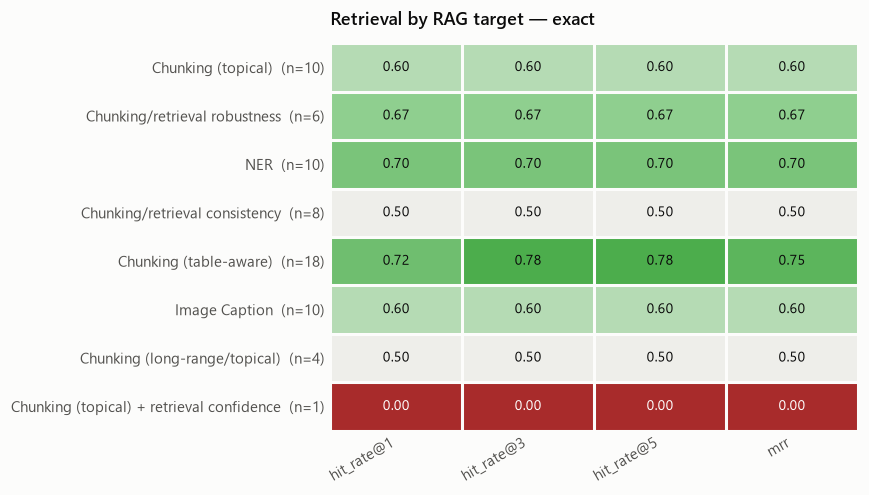

In [16]:
def retrieval_table(group, tol):
    rows = retrieval["aggregate"][group]
    t = pd.DataFrame({g: {**v[tol], "n": v["questions"]} for g, v in rows.items()}).T
    t = t.sort_values(["mrr", "n"], ascending=False)
    t.index = [f"{g}  (n={int(n)})" for g, n in zip(t.index, t["n"])]
    return t.drop(columns="n").astype(float)


def retrieval_heatmap(group, tol, title, height, cmap=BLUES):
    # Rows keep the within_1_page order so the exact and ±1 heatmaps line up.
    order = retrieval_table(group, "within_1_page").index
    fig, ax = plt.subplots(figsize=(8, height))
    heatmap(ax, retrieval_table(group, tol).loc[order], cmap=cmap)
    ax.set_title(f"{title} — {tol}")
    finish(fig, f"retrieval-{group.replace('_', '-')}-{tol.replace('_', '-')}")


retrieval_heatmap("by_rag_target", "exact", "Retrieval by RAG target", 4.6, cmap=RED_GREEN)

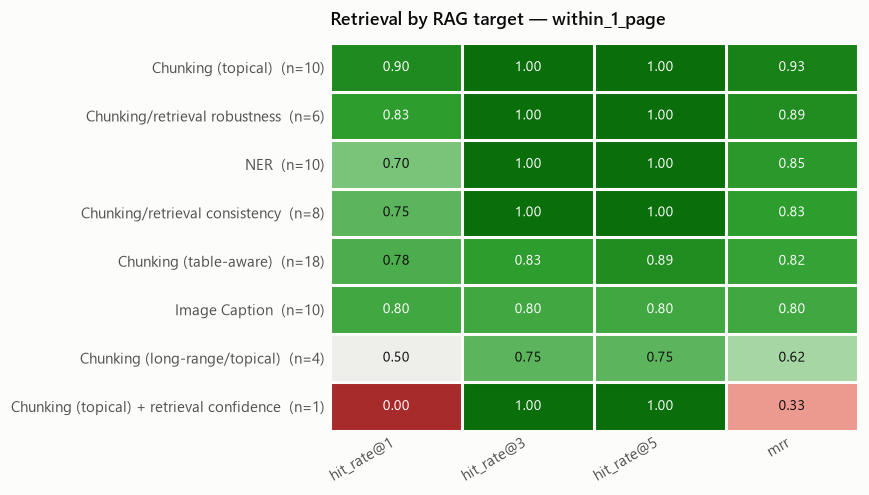

In [17]:
retrieval_heatmap("by_rag_target", "within_1_page", "Retrieval by RAG target", 4.6, cmap=RED_GREEN)

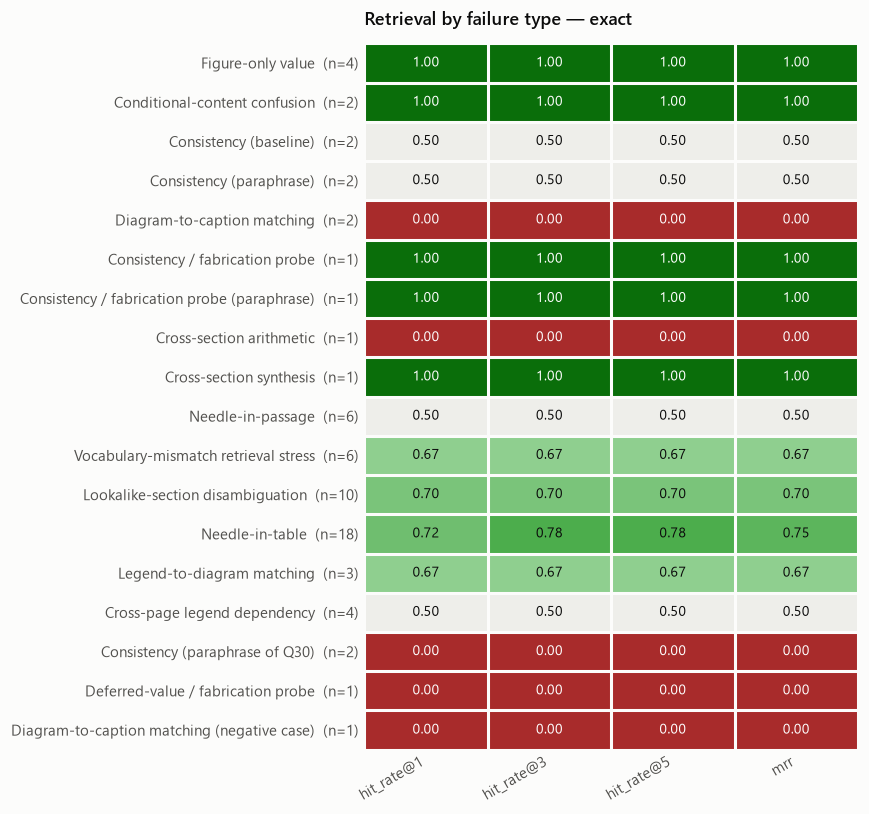

In [18]:
retrieval_heatmap("by_failure_type", "exact", "Retrieval by failure type", 7.5, cmap=RED_GREEN)

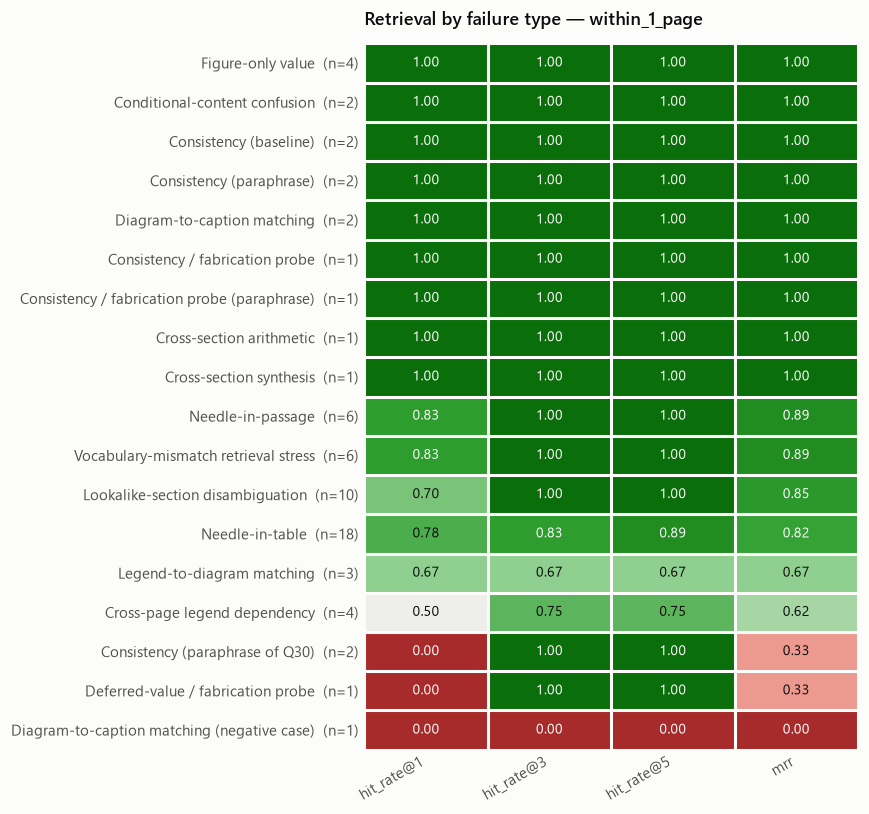

In [19]:
retrieval_heatmap("by_failure_type", "within_1_page", "Retrieval by failure type", 7.5, cmap=RED_GREEN)

## 4. Retrieval vs. generation — where does each question fail?

Joins the three files per question. A question is **retrieved** when the right page (±1) is in the top 5 context,
and **correct** when RAGAS `answer_accuracy` ≥ `ACCURACY_PASS`, as scored by the primary complete judge
(`luna` when it is complete, otherwise `qwen`). Skipped when no judge is complete.

| Outcome | Meaning |
|---|---|
| retrieved · correct | pipeline worked |
| retrieved · not correct | right context was there — generation (or chunk content) failed; includes partial credit |
| missed · correct | answered without the named page (neighbouring chunk, duplicate content, or model knowledge) |
| missed · not correct | retrieval failure |
| no page to retrieve | fabricated / absence questions, not scored for retrieval |

In [20]:
if PRIMARY:
    print(f"Correctness judged by {judge_label(PRIMARY)}")
    scores = scores_by_judge[PRIMARY]
    joined = (
        ans[["id", "question", "rag_target", "failure_type", "expected_answer", "answer", "cited_pages", "elapsed_s"]]
        .merge(scores[["id"] + METRICS], on="id", how="left")
        .merge(ret[["id", "within_1_page:hit@5", "within_1_page:first_relevant_rank"]], on="id", how="left")
    )
    retrieved = joined["within_1_page:hit@5"]
    correct = joined["answer_accuracy"] >= ACCURACY_PASS
    joined["outcome"] = np.select(
        [retrieved.isna(), (retrieved == True) & correct, (retrieved == True) & ~correct, (retrieved == False) & correct],
        ["no page to retrieve", "retrieved · correct", "retrieved · not correct", "missed · correct"],
        default="missed · not correct",
    )
    OUTCOMES = ["retrieved · correct", "retrieved · not correct", "missed · correct", "missed · not correct", "no page to retrieve"]
    OUTCOME_COLORS = SERIES[:4] + [AXIS]
    display(joined["outcome"].value_counts().reindex(OUTCOMES, fill_value=0).to_frame("questions"))
else:
    joined = None
    print("No judge has scored every question yet — section 4 is skipped.")

Correctness judged by luna (gpt-5.6-luna)


,questions
outcome,
retrieved · correct,39
retrieved · not correct,23
missed · correct,1
missed · not correct,4
no page to retrieve,3


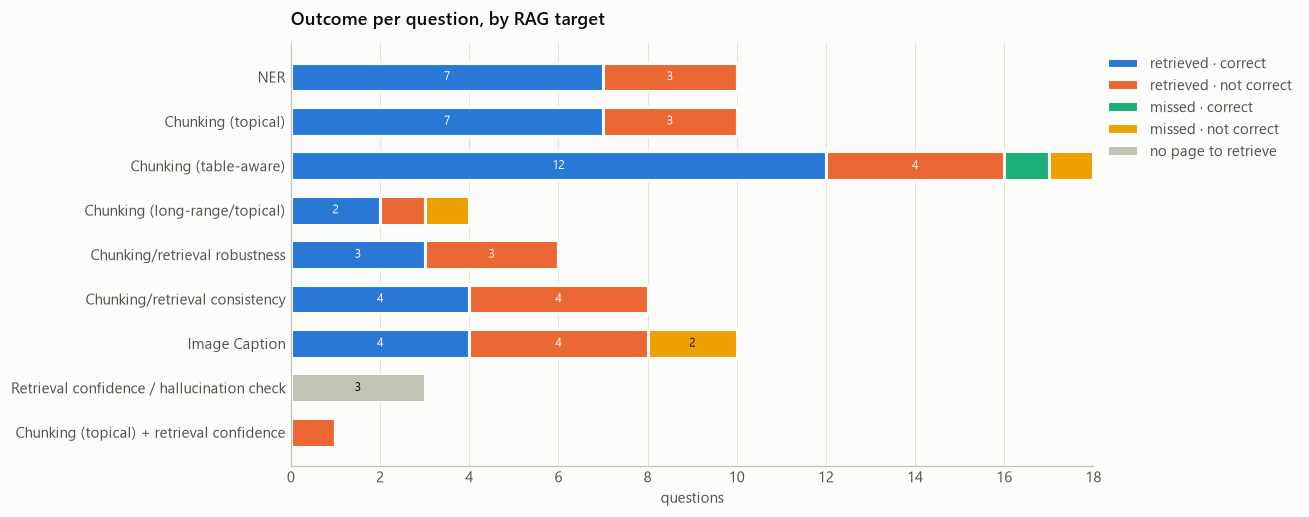

In [21]:
if joined is not None:
    tab = pd.crosstab(joined["rag_target"], joined["outcome"]).reindex(columns=OUTCOMES, fill_value=0)
    tab = tab.loc[(tab["retrieved · correct"] / tab.sum(axis=1)).sort_values().index]

    fig, ax = plt.subplots(figsize=(12, 4.8))
    left = np.zeros(len(tab))
    for outcome, color in zip(OUTCOMES, OUTCOME_COLORS):
        vals = tab[outcome].to_numpy()
        # white edge = 2px surface gap between stacked segments
        ax.barh(tab.index, vals, left=left, height=0.65, color=color, edgecolor=SURFACE, linewidth=2, label=outcome)
        for y, (l, v) in enumerate(zip(left, vals)):
            if v >= 2:
                ax.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=8,
                        color=INK if color in (SERIES[2], SERIES[3], AXIS) else "#ffffff")
        left += vals
    ax.set(xlabel="questions", title="Outcome per question, by RAG target")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    finish(fig, "outcome-by-target")

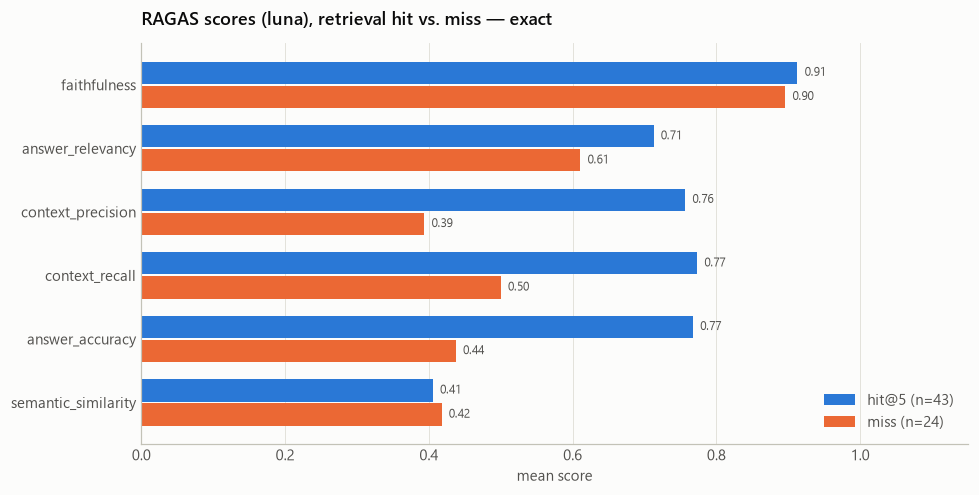

In [22]:
# Does retrieving the right page actually translate into better answers?


def hit_vs_miss(tol):
    if joined is None:
        return
    hits = ret[["id"] + [f"{tol}:hit@5" for tol in TOLS]].merge(scores_by_judge[PRIMARY][["id"] + METRICS], on="id")
    fig, ax = plt.subplots(figsize=(9, 4.6))
    y = np.arange(len(METRICS))[::-1]
    h = 0.38
    groups = {"hit@5": hits[hits[f"{tol}:hit@5"] == True], "miss": hits[hits[f"{tol}:hit@5"] == False]}
    for i, (label, df) in enumerate(groups.items()):
        vals = df[METRICS].mean().to_numpy()
        pos = y + (0.5 - i) * h
        ax.barh(pos, vals, height=h - 0.03, color=SERIES[i], label=f"{label} (n={len(df)})")
        for p, v in zip(pos, vals):
            if not np.isnan(v):
                ax.text(v + 0.01, p, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
    ax.set_yticks(y, METRICS)
    ax.set(xlim=(0, 1.15), xlabel="mean score", title=f"RAGAS scores ({PRIMARY}), retrieval hit vs. miss — {tol}")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    finish(fig, f"ragas-by-retrieval-hit-{tol.replace('_', '-')}")


hit_vs_miss("exact")

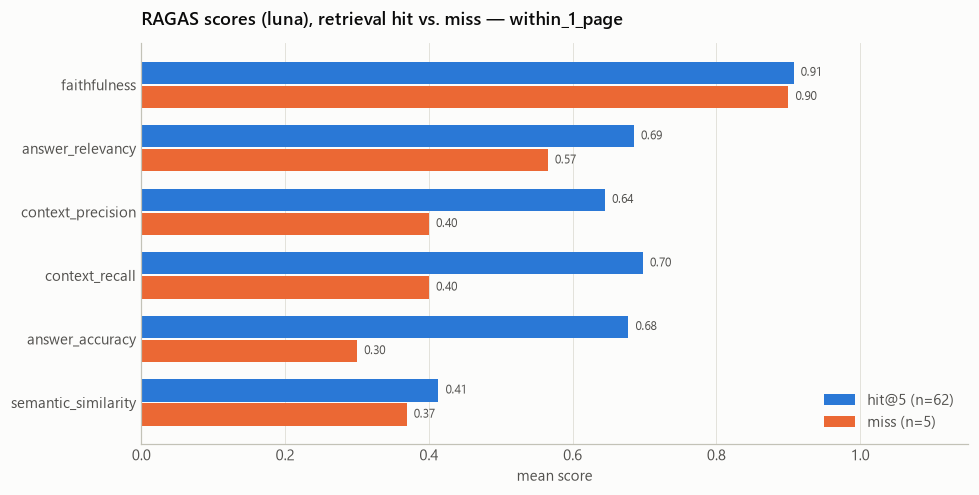

In [23]:
hit_vs_miss("within_1_page")

### Questions that did not get a correct answer

Sorted so generation failures (right context retrieved, wrong answer) come first.

In [24]:
if joined is not None:
    pd.set_option("display.max_colwidth", 160)
    failures = joined[~correct & (joined["outcome"] != "no page to retrieve")].copy()
    failures["answer"] = failures["answer"].str.replace(r"\s+", " ", regex=True).str.slice(0, 160)
    display(failures.sort_values(["outcome", "answer_accuracy", "id"])[
        ["id", "outcome", "rag_target", "question", "expected_answer", "answer",
         "answer_accuracy", "faithfulness", "context_recall", "within_1_page:first_relevant_rank"]
    ].set_index("id").style.format(precision=2, na_rep="–"))

,outcome,rag_target,question,expected_answer,answer,answer_accuracy,faithfulness,context_recall,within_1_page:first_relevant_rank
id,,,,,,,,,
47,missed · not correct,Image Caption,"In the same appendix, what screw size is used for the round-terminal (DIN 46223) connection, and what's its tightening spec?",M10-steel; tightened until a reliable connection is obtained (no torque figure given),The provided context does not include any information regarding the screw size and tightening specification for the round-terminal (DIN 46223) connection in the,0.00,1.00,0.00,–
50,missed · not correct,Image Caption,"In the direction-of-rotation diagram, which item number represents 'Reversing'?",item 9,"The context provided does not include any information about a direction-of-rotation diagram or item numbers related to 'Reversing'. Therefore, I cannot answer w",0.00,1.00,0.00,–
59,missed · not correct,Chunking (long-range/topical),"At maintenance level L3, what re-greasing check ('Check/Test' column) is specified for rolling bearings, per the maintenance program table?",V/R — According to bearing plate,The provided context does not specify any re-greasing check for rolling bearings at maintenance level L3 in the maintenance program table. It only mentions the,0.00,1.00,0.00,–
12,missed · not correct,Chunking (table-aware),"For a 250–500 mm gear coupling, what is the permissible angular misalignment?",0.05 mm (2 mil),"The permissible angular misalignment for a 250–500 mm gear coupling is 0.05 mm (1 mil), as shown in the recommended permissible misalignments table on page 49.",0.50,0.50,1.00,–
2,retrieved · not correct,Chunking (table-aware),"What is the Pt-100 resistance, in ohms, at exactly 40°C according to Table 11?",115.54 Ω,"The resistance of a Pt-100 sensor at 40°C is 100.00 ohms, as shown in Table 11.",0.00,0.00,0.00,2.00
3,retrieved · not correct,Chunking (table-aware),What is the tightening torque (Nm) for an oiled M20 bolt of property class 8.8?,360 Nm,The context does not provide the tightening torque for an oiled M20 bolt with property class 8.8. The available information only includes tightening torques for,0.00,1.00,0.00,1.00
4,retrieved · not correct,Chunking (table-aware),What is the tightening torque (Nm) for a dry M20 bolt of property class 8.8?,390 Nm,The context does not provide the tightening torque for a dry M20 bolt with property class 8.8. The available information only includes tightening torques for bo,0.00,1.00,0.00,1.00
15,retrieved · not correct,NER,What insulation resistance is acceptable for a new stator under extremely warm and humid measuring conditions?,values above 100 MΩ (vs >1000 MΩ for normal conditions),The context does not provide a specific acceptable insulation resistance value for a new stator in high temperature and humidity conditions. It mentions that hi,0.00,1.00,0.00,2.00
29,retrieved · not correct,Chunking (topical),"What is the recommended brush pressure range on the slip ring, in mN/mm²?",18–20 mN/mm² (180–200 g/cm²),The context does not provide the specific recommended brush pressure range for slip rings in mN/mm². It mentions that the brush pressure should be within a spec,0.00,1.00,0.00,1.00
